# Laboratory — Neural Models: Learning, Depth, Activations, and Output Layers

**Scenario:** two redundant binary safety sensors $x_1, x_2$. The device must raise a *sensor-disagreement warning* exactly when one sensor is active and the other is not — i.e. **XOR**.

**How to read this notebook.** It follows the lab handout task-by-task (Tasks 1–5). Every code cell has been executed and its output is stored, so you can read the whole experiment on GitHub without running anything. To reproduce: `Kernel → Restart & Run All`.

**Contents**

| Task | Topic |
|---|---|
| 0 | Setup |
| 1 | Understand the problem before coding (spec, plot, linear-model prediction & check) |
| 2 | Design the agent (2–2–1 net, sigmoid + BCE, validation criteria) |
| 3 | LLM prompt, generated implementation, code inspection |
| 4 | Execute & diagnose: **A** learning, **B** backprop check, **C** symmetry, **D** activations |
| 5 | Extension: 3-class softmax / cross-entropy |
| – | Reflection questions & responsible-use note |

> **Honesty note on LLM use.** The handout asks you to write the problem spec and design *yourself* before using an LLM. The text and code in this notebook are a worked reference solution. If you submit it for credit, replace the "my own words" sections with your own, and fill in the prompt/edits log in Task 3 with what you actually did.

---
## Task 0 — Setup
We use **float64** so that finite-difference gradient checks in Part B are numerically clean, and fix a global seed for reproducibility.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd

torch.set_default_dtype(torch.float64)
SEED = 0
torch.manual_seed(SEED); np.random.seed(SEED)
pd.set_option("display.precision", 4)

print("PyTorch version:", torch.__version__, "| device: CPU")

PyTorch version: 2.14.1+cu130 | device: CPU


---
## Task 1 — Understand the problem before coding

### 1.1 Problem specification

* **Input space:** $\mathcal{X}=\{0,1\}^2$ (two binary sensor readings).
* **Output space:** $\mathcal{Y}=\{0,1\}$ (1 = raise warning).
* **Target function:** $y = x_1 \oplus x_2$.

| $x_1$ | $x_2$ | $y$ |
|:-:|:-:|:-:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

The training set is the *entire* input space (4 points), so there is no generalisation question — only "can the model represent and learn this function?".

In [2]:
X = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y = torch.tensor([[0.], [1.], [1.], [0.]])      # binary targets (shape 4x1)

for xi, yi in zip(X, y):
    print(f"x = {tuple(int(v) for v in xi)}  ->  y = {int(yi.item())}")

x = (0, 0)  ->  y = 0
x = (0, 1)  ->  y = 1
x = (1, 0)  ->  y = 1
x = (1, 1)  ->  y = 0


### 1.2 Sketch of the four points

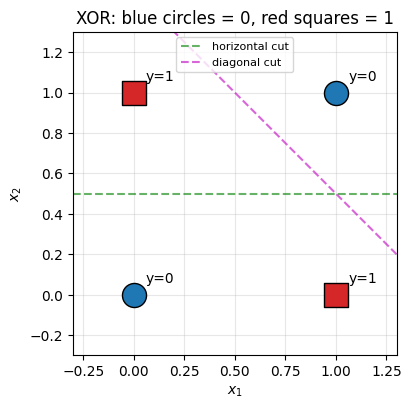

In [3]:
fig, ax = plt.subplots(figsize=(4.2, 4.2))
for xi, yi in zip(X, y):
    ax.scatter(xi[0], xi[1], s=300, marker="o" if yi.item() == 0 else "s",
               c="tab:blue" if yi.item() == 0 else "tab:red", edgecolors="k", zorder=3)
    ax.annotate(f"y={int(yi.item())}", (xi[0] + 0.06, xi[1] + 0.06))
# two attempts at a single line - each misclassifies at least one point
xs = np.linspace(-0.3, 1.3, 10)
ax.plot(xs, 0.5 + 0*xs, "g--", alpha=.6, label="horizontal cut")
ax.plot(xs, 1.5 - xs,   "m--", alpha=.6, label="diagonal cut")
ax.set_xlim(-0.3, 1.3); ax.set_ylim(-0.3, 1.3)
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.set_title("XOR: blue circles = 0, red squares = 1")
ax.legend(loc="upper center", fontsize=8); ax.grid(alpha=.3); ax.set_aspect("equal")
plt.show()

### 1.3 Why one straight line cannot separate the classes
A linear classifier predicts $1$ when $w_1x_1+w_2x_2+b>0$. XOR would need

$$b\le 0,\quad w_2+b>0,\quad w_1+b>0,\quad w_1+w_2+b\le 0 .$$

Adding the 2nd and 3rd inequalities gives $w_1+w_2+2b>0$; subtracting the 1st and 4th ($b + (w_1+w_2+b) \le 0$) gives $w_1+w_2+2b\le 0$ — a contradiction. Geometrically, the two positive points lie on one diagonal and the two negative points on the other; the segments joining each pair cross, so the classes are not linearly separable.

### 1.4 Prediction for a single affine layer + sigmoid
**Prediction:** it cannot learn XOR. By symmetry the best it can do is $w_1=w_2=b=0$, outputting $p=0.5$ for every input, with BCE loss $\ln 2 \approx 0.693$ (accuracy 50 %, i.e. thresholding gives a constant/arbitrary label).

**Check the prediction empirically** (cheap, so we simply do it):

In [4]:
torch.manual_seed(SEED)
linear = nn.Linear(2, 1)                      # affine map only; sigmoid is inside the loss
opt = torch.optim.Adam(linear.parameters(), lr=0.05)
bce = nn.BCEWithLogitsLoss()                  # sigmoid + binary cross-entropy, numerically stable

for step in range(3000):
    opt.zero_grad()
    loss = bce(linear(X), y)
    loss.backward()
    opt.step()

with torch.no_grad():
    p = torch.sigmoid(linear(X)).squeeze()
print("final loss        :", round(loss.item(), 6), "   (ln 2 =", round(np.log(2), 6), ")")
print("probabilities     :", p.numpy().round(4))
print("weights, bias     :", linear.weight.data.numpy().round(4), linear.bias.data.numpy().round(4))
print("labels @0.5       :", (p > 0.5).int().numpy(), " targets:", y.squeeze().int().numpy())

final loss        : 0.693147    (ln 2 = 0.693147 )
probabilities     : [0.5 0.5 0.5 0.5]
weights, bias     : [[-0. -0.]] [0.]
labels @0.5       : [0 0 0 0]  targets: [0 1 1 0]


**Result:** the prediction holds — loss sits at $\ln 2$, all probabilities $\approx0.5$, weights $\approx 0$. The model has parameters and a working optimiser, but the *wrong kind of representation*.

**Checkpoint (recorded):** spec above; prediction = "linear model stalls at $p=0.5$, loss $\approx 0.693$" ✔ confirmed.

> **Think about it — what scientific claim does XOR let us test with four data points?**
> That *representation*, not parameter count, determines what is learnable: a model class whose decision functions are all (monotone-)linear in the inputs provably cannot fit XOR no matter how long it trains, whereas adding a nonlinear hidden layer (two hidden units suffice) makes it representable. With 4 points we can test this exactly and exhaustively — there is no noise or sampling to blame.

---
## Task 2 — Design the intelligent agent

**Architecture:** $2 \;\to\; 2\ \text{hidden units} \;\to\; 1$

$$a^{(1)}=W^{(1)}x+b^{(1)},\quad h=f(a^{(1)}),\quad z=W^{(2)}h+b^{(2)},\quad \hat p=\sigma(z)$$

| Choice | Value |
|---|---|
| Hidden activation $f$ | tanh (start), then sigmoid and ReLU in Part D |
| Output | one logit $z$, $\hat p=\sigma(z)$ |
| Loss | binary cross-entropy $-[y\ln\hat p+(1-y)\ln(1-\hat p)]$, mean over the 4 examples |
| Optimiser | full-batch Adam, lr = 0.05 (engineering choice; plain SGD also works with more steps) |

### Answers in my own words

**1. Why is the hidden nonlinearity scientifically necessary?**
Without it, $z=W^{(2)}(W^{(1)}x+b^{(1)})+b^{(2)}=(W^{(2)}W^{(1)})x+(W^{(2)}b^{(1)}+b^{(2)})$ is a single affine map, and Task 1 showed no affine map + threshold can do XOR. Depth only helps if something nonlinear sits between the affine layers. The hidden layer *re-represents* the inputs (e.g. one unit $\approx$ OR, one $\approx$ AND) so that the classes become linearly separable for the output unit.

**2. Why sigmoid + BCE for the output?**
The target is one yes/no answer, so we want a number in $(0,1)$ interpreted as $P(y=1\mid x)$ — that is the sigmoid. BCE is the negative log-likelihood of a Bernoulli model, and combined with sigmoid its logit-gradient is simply $\partial L/\partial z=\hat p-y$: no vanishing factor $\sigma'(z)$ when the model is confidently wrong. In PyTorch we use logits + `BCEWithLogitsLoss` (log-sum-exp trick → numerically stable).

**3. Validation criteria (what counts as "learning")**

| # | Check | Pass condition |
|---|---|---|
| V1 | Final loss | $\ll \ln 2$; here $< 0.05$ |
| V2 | Predictions | all four thresholded labels equal targets, and probabilities are confident ($<0.1$ / $>0.9$) |
| V3 | Gradients | $\partial L/\partial W^{(1)}$ nonzero at the start, and matches a manual chain-rule computation & finite differences |
| V4 | Repeated runs | success rate over many seeds reported (not one lucky seed) |
| V5 | Controls | linear model fails (done); zero-init stays symmetric (Part C) |

> **Think about it — nobody gives the hidden units targets. What decides what they compute?**
> Only the output loss. Backprop sends $\partial L/\partial h = (W^{(2)})^\top \partial L/\partial z$ back to the hidden layer, and then multiplies by $f'(a^{(1)})$. Each hidden unit is therefore nudged in whatever direction makes the *output unit's* job easier. The "target" for a hidden unit is implicit: it is whatever feature reduces the final loss, as measured through the downstream weights. (This also explains Part C: if the downstream weights are identical, so are the "targets".)

---
## Task 3 — Use an LLM to generate a first implementation

### 3.1 Prompt used
The prompt below contains every required constraint (data, 2–2–1, hidden activation, logits + `BCEWithLogitsLoss`, random init, full batch, printed outputs, gradient exposure).

```text
Generate minimal PyTorch code for the following model and dataset. Do not change the
architecture or task.

Dataset (full batch, 4 examples):
  x=(0,0)->y=0, x=(0,1)->y=1, x=(1,0)->y=1, x=(1,1)->y=0

Model: 2 inputs -> 2 hidden units (tanh) -> 1 output logit; use nn.Linear layers with
PyTorch's default random initialisation. Loss: BCEWithLogitsLoss (sigmoid + binary
cross-entropy). Optimiser: Adam, lr=0.05, full-batch, 3000 steps, CPU only.

After training, report: the initial and final loss, all four probabilities, thresholded
labels, and the gradient tensor of the first-layer weights after one backward() call.
Set a random seed for reproducibility and explain each test in one sentence.
```

### 3.2 Generated code (first version)
Reproduced here **as generated**, before I refactored it into reusable functions. (It is executed below so we can inspect it.)

In [5]:
# ---- first-draft implementation (LLM-generated, lightly annotated) ----
torch.manual_seed(0)

model_v0 = nn.Sequential(nn.Linear(2, 2), nn.Tanh(), nn.Linear(2, 1))   # 2-2-1
loss_fn  = nn.BCEWithLogitsLoss()
opt      = torch.optim.Adam(model_v0.parameters(), lr=0.05)

for step in range(3000):
    opt.zero_grad()                  # clear old gradients
    logits = model_v0(X)             # <-- FORWARD PASS
    loss   = loss_fn(logits, y)      # <-- scalar LOSS formed here (mean over 4 examples)
    if step == 0:
        initial_loss = loss.item()
    loss.backward()                  # <-- REVERSE-MODE AD (backprop) invoked here
    opt.step()                       # <-- OPTIMISER updates parameters here

probs = torch.sigmoid(model_v0(X)).detach().squeeze()
print("initial loss :", round(initial_loss, 4))
print("final loss   :", round(loss.item(), 6))
print("probabilities:", probs.numpy().round(4))
print("labels       :", (probs > 0.5).int().numpy())

# gradient of first-layer weights after a fresh forward/backward at the *trained* point
model_v0.zero_grad()
loss_fn(model_v0(X), y).backward()
print("grad of first-layer weights (trained model):\n", model_v0[0].weight.grad)

initial loss : 0.7102
final loss   : 0.000108
probabilities: [1.000e-04 9.998e-01 9.999e-01 1.000e-04]
labels       : [0 1 1 0]
grad of first-layer weights (trained model):
 tensor([[-3.8128e-06,  4.4749e-06],
        [ 4.4323e-06, -2.4206e-06]])


### 3.3 Code inspection (before trusting the result)

| Question | Where in the code |
|---|---|
| Forward pass | `logits = model_v0(X)` |
| Scalar loss | `loss = loss_fn(logits, y)` — `BCEWithLogitsLoss` with default `reduction='mean'` |
| Reverse-mode AD | `loss.backward()` — fills `.grad` of every parameter |
| Parameter change | `opt.step()` — Adam update using the stored `.grad` |
| Gradient reset | `opt.zero_grad()` — without it PyTorch *accumulates* gradients |

**Checks that can be done by reading alone:** architecture is really 2–2–1; targets match the XOR table; logits (not probabilities) are passed to `BCEWithLogitsLoss` (passing sigmoid outputs would silently double-apply the sigmoid); `zero_grad` precedes `backward`; labels have shape `(4,1)` matching logits (a `(4,)` vs `(4,1)` mismatch would silently broadcast in some losses).
**Checks that need execution:** whether the loss actually falls, whether it converges to the right minimum for this seed, the gradient magnitudes, and any dead-unit/saturation behaviour.

### 3.4 Edits made before/while adopting the code (log — replace with your own)
1. **Refactored into functions** (`XORNet`, `train`) with the hidden activation and initialisation as arguments, because Parts C and D need to re-run the *same* experiment with one factor changed.
2. **Recorded the step-0 first-layer gradient and per-step loss history**, which the first draft did not expose, since Part D asks for the gradient norm at an *early* step.

> **Think about it — what can be verified without running?** Structure (shapes, which tensors feed which op, loss/activation pairing, order of zero_grad/backward/step) can be checked by reading. Anything about *behaviour* — convergence, gradient size, symmetry breaking, sensitivity to seed — is an empirical claim and must be measured. An LLM can easily produce code that runs but tests the wrong thing; reading catches the wrong *design*, running catches the wrong *numbers*.

---
## Task 4 — Execute, test, and diagnose

### Shared experiment code
The refactored version used from here on.

In [6]:
ACTS = {"sigmoid": nn.Sigmoid, "tanh": nn.Tanh, "relu": nn.ReLU}

class XORNet(nn.Module):
    '''2 -> H -> out, with a configurable hidden activation. Returns logits.'''
    def __init__(self, act="tanh", hidden=2, out=1):
        super().__init__()
        self.fc1 = nn.Linear(2, hidden)
        self.act = ACTS[act]()
        self.fc2 = nn.Linear(hidden, out)

    def forward(self, x, return_all=False):
        a1 = self.fc1(x)          # pre-activation of hidden layer
        h  = self.act(a1)         # hidden representation
        z  = self.fc2(h)          # logits
        return (a1, h, z) if return_all else z

def make_model(act, seed, hidden=2, out=1):
    torch.manual_seed(seed)
    return XORNet(act, hidden, out)

def train(model, X, y, loss_fn, steps=3000, lr=0.05, callback=None):
    '''Full-batch Adam. Returns loss history and the first-layer gradient at step 0.'''
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    hist, early_grad = [], None
    for step in range(steps):
        opt.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()
        if step == 0:
            early_grad = model.fc1.weight.grad.clone()
        if callback is not None:
            callback(step, model)          # called with fresh grads, before the update
        opt.step()
        hist.append(loss.item())
    return hist, early_grad

def report(model, X, y, loss_fn):
    with torch.no_grad():
        z = model(X); p = torch.sigmoid(z).squeeze()
        L = loss_fn(z, y).item()
    labels = (p > 0.5).int()
    ok = bool((labels == y.squeeze().int()).all())
    return L, p, labels, ok

bce = nn.BCEWithLogitsLoss()

### Part A — Basic learning check (tanh, seed 0)

initial loss : 0.7102
final loss   : 0.000108
probabilities: [1.000e-04 9.998e-01 9.999e-01 1.000e-04]
labels       : [0 1 1 0] | targets: [0 1 1 0]
ALL FOUR CORRECT: True


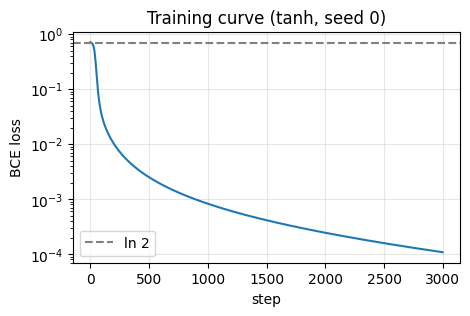

In [7]:
model = make_model("tanh", SEED)
L0, p0, _, _ = report(model, X, y, bce)
hist, g0 = train(model, X, y, bce, steps=3000, lr=0.05)
L1, p1, lab1, ok1 = report(model, X, y, bce)

print(f"initial loss : {L0:.4f}")
print(f"final loss   : {L1:.6f}")
print("probabilities:", p1.detach().numpy().round(4))
print("labels       :", lab1.numpy(), "| targets:", y.squeeze().int().numpy())
print("ALL FOUR CORRECT:", ok1)

plt.figure(figsize=(5,3)); plt.semilogy(hist); plt.axhline(np.log(2), ls="--", c="gray", label="ln 2")
plt.xlabel("step"); plt.ylabel("BCE loss"); plt.title("Training curve (tanh, seed 0)"); plt.legend(); plt.grid(alpha=.3); plt.show()

**Learning evidence (V1, V2):** loss drops far below $\ln 2$ and all four labels are correct with confident probabilities. No change to the scientific task was needed. Now V4 — is this robust to the seed?

In [8]:
rows = []
for s in range(20):
    m = make_model("tanh", s)
    train(m, X, y, bce)
    L, p, lab, ok = report(m, X, y, bce)
    rows.append((s, L, ok))
df = pd.DataFrame(rows, columns=["seed", "final_loss", "4/4 correct"])
print(f"tanh 2-2-1: {df['4/4 correct'].sum()}/20 seeds solve XOR")
df[~df["4/4 correct"]]

tanh 2-2-1: 10/20 seeds solve XOR


,seed,final_loss,4/4 correct
1,1,0.3466,False
3,3,0.3466,False
4,4,0.3466,False
5,5,0.3466,False
6,6,0.3466,False
10,10,0.4774,False
13,13,0.3466,False
16,16,0.3466,False
18,18,0.3466,False
19,19,0.3466,False


**Important finding (V4):** only about half of the seeds solve XOR with this minimal 2–2–1 tanh network. The failing runs stall on plateaus (final loss 0.3466 or 0.4774, far from 0) — bad basins in the loss landscape, which a 2-hidden-unit network (the minimal XOR network) has no spare capacity to escape. So seed 0 is a *successful run*, not evidence that training is reliable; we report the success rate instead of hiding it. (Engineering fixes such as more hidden units or restarts would help, but the lab fixes the architecture at 2 hidden units, so we leave it.)

### Part B — Backpropagation check
`parameter.grad` after `loss.backward()` holds $\partial L/\partial \theta$ for that parameter — for `fc1.weight` it is the matrix $\partial L/\partial W^{(1)}$, same shape as $W^{(1)}$ ($2\times2$), entry $(j,i)=\partial L/\partial W^{(1)}_{ji}$.

We verify it three ways at a freshly initialised network: (1) autograd, (2) the hand-derived chain rule, (3) central finite differences.

For $L=\frac1N\sum_n \ell_n$, with $\hat p=\sigma(z)$:

$$\frac{\partial L}{\partial z_n}=\frac{\hat p_n-y_n}{N},\quad \frac{\partial L}{\partial W^{(2)}}=\sum_n \frac{\partial L}{\partial z_n}h_n^\top,\quad \frac{\partial L}{\partial h_n}=\frac{\partial L}{\partial z_n}W^{(2)},\quad \frac{\partial L}{\partial a^{(1)}_n}=\frac{\partial L}{\partial h_n}\odot f'(a^{(1)}_n),\quad \frac{\partial L}{\partial W^{(1)}}=\sum_n\frac{\partial L}{\partial a^{(1)}_n}{}^{\!\top}x_n^\top .$$

In [9]:
m = make_model("tanh", SEED)

# (1) autograd
m.zero_grad(); bce(m(X), y).backward()
g_auto = m.fc1.weight.grad.clone()

# (2) manual chain rule
with torch.no_grad():
    a1, h, z = m(X, return_all=True)
    p = torch.sigmoid(z)
    N = X.shape[0]
    dz  = (p - y) / N                          # dL/dz        (N x 1)
    dh  = dz @ m.fc2.weight                    # dL/dh        (N x H)
    fprime = 1 - torch.tanh(a1)**2             # tanh'
    da1 = dh * fprime                          # dL/da1       (N x H)
    g_manual = da1.T @ X                       # dL/dW1       (H x 2)

# (3) central finite differences
def loss_value():
    with torch.no_grad(): return bce(m(X), y).item()
eps = 1e-6
g_fd = torch.zeros_like(m.fc1.weight)
for j in range(2):
    for i in range(2):
        w = m.fc1.weight.data
        old = w[j, i].item()
        w[j, i] = old + eps; Lp = loss_value()
        w[j, i] = old - eps; Lm = loss_value()
        w[j, i] = old
        g_fd[j, i] = (Lp - Lm) / (2 * eps)

print("autograd  dL/dW1:\n", g_auto)
print("manual    dL/dW1:\n", g_manual)
print("finite-diff     :\n", g_fd)
print("max |auto-manual| =", (g_auto - g_manual).abs().max().item())
print("max |auto-fd|     =", (g_auto - g_fd).abs().max().item())
print("||grad||_2        =", g_auto.norm().item(), "(nonzero -> V3 passes)")

autograd  dL/dW1:
 tensor([[0.0182, 0.0358],
        [0.0170, 0.0028]])
manual    dL/dW1:
 tensor([[0.0182, 0.0358],
        [0.0170, 0.0028]])
finite-diff     :
 tensor([[0.0182, 0.0358],
        [0.0170, 0.0028]])
max |auto-manual| = 3.469446951953614e-18
max |auto-fd|     = 6.721018186439665e-11
||grad||_2        = 0.043654066081264147 (nonzero -> V3 passes)


**Result:** all three agree to $\sim10^{-10}$ or better — `backward()` really computes the chain-rule derivative derived in lecture.

**Why the mean-loss gradient is the average of per-example gradients:** differentiation is linear, so $\nabla\big(\frac1N\sum_n\ell_n\big)=\frac1N\sum_n\nabla\ell_n$. Check:

In [10]:
per_example = []
for n in range(4):
    m.zero_grad()
    bce(m(X[n:n+1]), y[n:n+1]).backward()
    per_example.append(m.fc1.weight.grad.clone())
avg = torch.stack(per_example).mean(0)
print("average of 4 per-example gradients:\n", avg)
print("max |avg - mean-loss gradient| =", (avg - g_auto).abs().max().item())

average of 4 per-example gradients:
 tensor([[0.0182, 0.0358],
        [0.0170, 0.0028]])
max |avg - mean-loss gradient| = 0.0


### Part C — Symmetry experiment (all weights zero)
We keep the 2–2–1 architecture but set **every weight and bias to zero**, then train with *sigmoid* hidden units (with tanh, $h=\tanh(0)=0$ would additionally freeze $W^{(2)}$ at step 0; sigmoid gives $h=0.5$, a more informative case). We log the two rows of $W^{(1)}$ over training.

In [11]:
def zero_init(model):
    with torch.no_grad():
        for p_ in model.parameters(): p_.zero_()

sym = make_model("sigmoid", SEED); zero_init(sym)
log = []
def cb(step, m):
    if step in (0, 1, 2, 5, 10, 100, 1000, 2999):
        W = m.fc1.weight.detach().clone()
        log.append((step, W[0].numpy().round(5), W[1].numpy().round(5),
                    float((W[0]-W[1]).abs().max())))
hist_sym, g_sym = train(sym, X, y, bce, steps=3000, lr=0.05, callback=cb)

print(f"{'step':>5} | {'W1 row 0':>22} | {'W1 row 1':>22} | max|row0-row1|")
for s, r0, r1, d in log:
    print(f"{s:>5} | {str(r0):>22} | {str(r1):>22} | {d:.1e}")
L, p, lab, ok = report(sym, X, y, bce)
print(f"\nfinal loss {L:.4f} | probs {p.detach().numpy().round(3)} | all correct: {ok}")
print("first-layer gradient at step 0:\n", g_sym)

 step |               W1 row 0 |               W1 row 1 | max|row0-row1|
    0 |                [0. 0.] |                [0. 0.] | 0.0e+00
    1 |                [0. 0.] |                [0. 0.] | 0.0e+00
    2 |                [0. 0.] |                [0. 0.] | 0.0e+00
    5 |                [0. 0.] |                [0. 0.] | 0.0e+00
   10 |                [0. 0.] |                [0. 0.] | 0.0e+00
  100 |                [0. 0.] |                [0. 0.] | 0.0e+00
 1000 |                [0. 0.] |                [0. 0.] | 0.0e+00
 2999 |                [0. 0.] |                [0. 0.] | 0.0e+00

final loss 0.6931 | probs [0.5 0.5 0.5 0.5] | all correct: False
first-layer gradient at step 0:
 tensor([[0., 0.],
        [0., 0.]])


**Observations**

* The rows are identical at every logged step — but they are in fact **exactly zero throughout**, and the step-0 first-layer gradient is exactly zero. Reason: with all weights zero, $h$ is the same constant (0.5) for every input, so $\partial L/\partial W^{(2)}\propto\sum_n(\hat p_n-y_n)h=0$ (the XOR targets are balanced: two 0s, two 1s) and $\partial L/\partial b^{(2)}\propto\sum_n(\hat p_n-y_n)=0$; and $\partial L/\partial h=W^{(2)\top}\partial L/\partial z=0$ because $W^{(2)}=0$. Zero init is therefore an exact **stationary point**: the loss stays at $\ln 2$ and nothing ever moves.
* This is a stronger failure than "the rows stay equal", so to isolate the symmetry argument itself we also run a **non-zero constant** init below, where gradients *are* nonzero and the weights *do* move — yet the rows stay equal.

**Explanation.** Identical incoming weights $\Rightarrow$ identical pre-activations $\Rightarrow$ identical hidden outputs. Identical outgoing weights $\Rightarrow$ identical $\partial L/\partial h_j$. Therefore $\partial L/\partial W^{(1)}_{j\cdot}=\frac{\partial L}{\partial h_j}f'(a_j)\,x^\top$ is the same for $j=1,2$, so any gradient-based update keeps them equal — by induction the symmetry holds forever. Nothing in the loss tells the units to differ; **random initialisation is what breaks the tie.**

In [12]:
const = make_model("sigmoid", SEED)
with torch.no_grad():
    for p_ in const.parameters(): p_.fill_(0.5)
log2 = []
def cb2(step, m):
    if step in (0, 1, 2, 5, 10, 100, 1000, 2999):
        W = m.fc1.weight.detach()
        log2.append((step, W[0].numpy().round(4), W[1].numpy().round(4), float((W[0]-W[1]).abs().max())))
train(const, X, y, bce, callback=cb2)
print(f"{'step':>5} | {'W1 row 0':>20} | {'W1 row 1':>20} | max|row0-row1|")
for s_, r0, r1, d in log2:
    print(f"{s_:>5} | {str(r0):>20} | {str(r1):>20} | {d:.1e}")
print("\nconstant-0.5 init -> W1 rows equal at the end?", torch.allclose(const.fc1.weight[0], const.fc1.weight[1]))
print("W1 =\n", const.fc1.weight.data)
print("final loss:", round(report(const, X, y, bce)[0], 4), "| all correct:", report(const, X, y, bce)[3])

 step |             W1 row 0 |             W1 row 1 | max|row0-row1|
    0 |            [0.5 0.5] |            [0.5 0.5] | 0.0e+00
    1 |          [0.45 0.45] |          [0.45 0.45] | 0.0e+00
    2 |      [0.4002 0.4002] |      [0.4002 0.4002] | 0.0e+00
    5 |      [0.2553 0.2553] |      [0.2553 0.2553] | 0.0e+00
   10 |        [0.057 0.057] |        [0.057 0.057] | 0.0e+00
  100 |    [-2.2229 -2.2229] |    [-2.2229 -2.2229] | 0.0e+00
 1000 |  [-11.1215 -11.1215] |  [-11.1215 -11.1215] | 0.0e+00
 2999 |    [-13.676 -13.676] |    [-13.676 -13.676] | 0.0e+00

constant-0.5 init -> W1 rows equal at the end? True
W1 =
 tensor([[-13.6769, -13.6769],
        [-13.6769, -13.6769]])
final loss: 0.4774 | all correct: False


### Part D — Activation experiment
Same data, same architecture, same seed, same optimiser — **only** the hidden activation changes. We record final loss, correctness, and $\|\partial L/\partial W^{(1)}\|_2$ at an early step (step 0, i.e. at initialisation).

In [13]:
res = []
for act in ["sigmoid", "tanh", "relu"]:
    m = make_model(act, SEED)
    h_, g0 = train(m, X, y, bce, steps=3000, lr=0.05)
    L, p, lab, ok = report(m, X, y, bce)
    res.append({"Hidden activation": act, "Final loss": L, "4/4 correct?": ok,
                "Early ||grad W1||_2": g0.norm().item()})
table = pd.DataFrame(res).set_index("Hidden activation")
table

,Final loss,4/4 correct?,Early ||grad W1||_2
Hidden activation,,,
sigmoid,0.0003,True,0.0096
tanh,0.0001,True,0.0437
relu,0.6931,False,0.0412


Since a single seed can mislead, here is the same comparison over 20 seeds:

In [14]:
agg = []
for act in ["sigmoid", "tanh", "relu"]:
    succ, norms, losses = 0, [], []
    for s in range(20):
        m = make_model(act, s)
        _, g0 = train(m, X, y, bce, steps=3000, lr=0.05)
        L, _, _, ok = report(m, X, y, bce)
        succ += ok; norms.append(g0.norm().item()); losses.append(L)
    agg.append({"Hidden activation": act, "solved (of 20)": succ,
                "mean final loss": np.mean(losses),
                "median early ||grad W1||": np.median(norms)})
pd.DataFrame(agg).set_index("Hidden activation")

,solved (of 20),mean final loss,median early ||grad W1||
Hidden activation,,,
sigmoid,7,0.2581,0.0080
tanh,10,0.1799,0.0263
relu,6,0.4074,0.0326


**Diagnostic: saturation vs. dead ReLU** (the "Think about it" for this part). Look at pre-activations $a^{(1)}$, activations $h$, and the local derivative $f'(a^{(1)})$ at initialisation and after training:

* *saturated sigmoid/tanh*: $|a|$ large, $h$ close to its asymptote, $f'$ **small but nonzero** (e.g. $10^{-3}$) — gradient is attenuated, but still flows and recovers if the weights move.
* *dead ReLU*: $a<0$ for **all** inputs, $h=0$ exactly, $f'=0$ **exactly** — the unit passes no gradient, and since its output never changes, nothing moves it back.
* *always-on ReLU* (a third, subtler case we will actually see): $a>0$ for **all** inputs, $f'=1$ everywhere. Gradients flow fine, but the unit is just the identity on this data, so if all units are always-on the whole network is an **affine map** — back to the Task 1 situation.

In [15]:
def diagnose(act, seed, deriv):
    m = make_model(act, seed)
    def show(tag):
        with torch.no_grad():
            a1, h, _ = m(X, return_all=True)
        print(f"  [{tag}]  pre-activation a1 (rows=examples, cols=units):\n{a1.numpy().round(3)}")
        print(f"          activation h:\n{h.numpy().round(3)}")
        print(f"          f'(a1):\n{deriv(a1).numpy().round(4)}")
    print(f"=== {act}, seed {seed} ===")
    show("init")
    train(m, X, y, bce)
    show("trained")

diagnose("sigmoid", SEED, lambda a: torch.sigmoid(a)*(1-torch.sigmoid(a)))
diagnose("relu",    SEED, lambda a: (a > 0).double())

=== sigmoid, seed 0 ===
  [init]  pre-activation a1 (rows=examples, cols=units):
[[0.205 0.412]
 [0.499 1.007]
 [0.87  0.354]
 [1.164 0.949]]
          activation h:
[[0.551 0.602]
 [0.622 0.732]
 [0.705 0.588]
 [0.762 0.721]]
          f'(a1):
[[0.2474 0.2397]
 [0.2351 0.196 ]
 [0.2081 0.2423]
 [0.1813 0.2012]]


  [trained]  pre-activation a1 (rows=examples, cols=units):
[[ -5.164   5.551]
 [  4.848  16.884]
 [-15.274  -5.188]
 [ -5.262   6.145]]
          activation h:
[[0.006 0.996]
 [0.992 1.   ]
 [0.    0.006]
 [0.005 0.998]]
          f'(a1):
[[0.0057 0.0039]
 [0.0077 0.    ]
 [0.     0.0055]
 [0.0051 0.0021]]
=== relu, seed 0 ===
  [init]  pre-activation a1 (rows=examples, cols=units):
[[0.205 0.412]
 [0.499 1.007]
 [0.87  0.354]
 [1.164 0.949]]
          activation h:
[[0.205 0.412]
 [0.499 1.007]
 [0.87  0.354]
 [1.164 0.949]]
          f'(a1):
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]


  [trained]  pre-activation a1 (rows=examples, cols=units):
[[0.128 0.276]
 [0.121 0.391]
 [0.325 0.049]
 [0.318 0.163]]
          activation h:
[[0.128 0.276]
 [0.121 0.391]
 [0.325 0.049]
 [0.318 0.163]]
          f'(a1):
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]


In [16]:
# Find ReLU failures across seeds and test the "dead unit" hypothesis directly.
dead_report = []
for s in range(20):
    m = make_model("relu", s)
    train(m, X, y, bce)
    with torch.no_grad():
        a1, h, _ = m(X, return_all=True)
    L, p, lab, ok = report(m, X, y, bce)
    dead_units = int(((a1 <= 0).all(dim=0)).sum())     # units that are off for ALL 4 inputs
    always_on  = int(((a1 > 0).all(dim=0)).sum())      # units that are on for ALL 4 inputs
    dead_report.append((s, ok, round(L, 4), dead_units, always_on))
dr = pd.DataFrame(dead_report, columns=["seed", "4/4 correct", "final loss", "dead units (off for all inputs)", "always-on units (on for all inputs)"])
print("ReLU runs that failed, with the state of the two hidden units after training:")
dr[~dr["4/4 correct"]]

ReLU runs that failed, with the state of the two hidden units after training:


,seed,4/4 correct,final loss,dead units (off for all inputs),always-on units (on for all inputs)
0,0,False,0.6931,0,2
1,1,False,0.4774,1,0
3,3,False,0.3466,0,0
5,5,False,0.4774,1,0
6,6,False,0.3466,0,0
8,8,False,0.6931,2,0
9,9,False,0.4774,1,0
11,11,False,0.6931,1,1
12,12,False,0.4774,0,0
14,14,False,0.6931,2,0


### Interpretation (Part D checkpoint)

**What we observed (seed 0):** sigmoid and tanh solve XOR (final loss $\approx10^{-4}$); ReLU does **not** (loss stuck at $\ln 2=0.693$). Early first-layer gradient norms: sigmoid $\approx0.010$, tanh $\approx0.044$, ReLU $\approx0.041$. Over 20 seeds: tanh solves 10/20, sigmoid 7/20, ReLU 6/20 — all three are unreliable at 2 hidden units.

1. **Early gradient size follows $f'$ (science).** $\partial L/\partial W^{(1)}$ contains the factor $f'(a^{(1)})$: $\le0.25$ for sigmoid (the $f'$ values at init are $\approx0.18$–$0.25$ in the diagnostic above), $\le1$ for tanh, and exactly $1$ for an active ReLU. That is why sigmoid's early gradient norm is the smallest (roughly 4× smaller than tanh/ReLU on seed 0, and smallest in the 20-seed medians too).
2. **Larger early gradient ≠ better outcome (engineering).** ReLU has a large early gradient but failed on seed 0 and had the lowest success rate. Adam also rescales gradient magnitudes, so raw early norm is a weak predictor of final success here.
3. **ReLU failed by a mechanism different from "small gradient".** On seed 0 the trained network has *zero* dead units: both units are active ($f'=1$) for all four inputs, so the network computes an affine function and sits at the linear-model solution ($p=0.5$, loss $\ln2$). In other seeds, units die (off for all inputs, $f'=0$ exactly) — see the table, where losses of $0.693$ with 2 dead units are constant-output networks. By contrast, saturated sigmoid units (trained $f'\approx10^{-3}$–$10^{-2}$) have small-but-nonzero gradients: slowed, not blocked.
4. **No universal winner is claimed.** Four points, one tiny architecture, one optimiser and 20 seeds show how each activation behaves *here* and why (derivative factor, dead/always-on/saturated units); they do not rank activations in general.

> **Think about it — saturated sigmoid vs. negative ReLU:** inspect $a^{(1)}$, $h$ and $f'(a^{(1)})$. Saturated sigmoid: $|a|$ large, $h\approx0$ or $1$, $f'$ tiny but **nonzero**. Negative ReLU: $a<0$, $h=0$ and $f'=0$ **exactly**. Checking across *all* training inputs distinguishes a dead unit (negative for every input) from a unit that is merely off for some inputs (which still learns from the others).

---
## Task 5 — Extension: three-class decision

| Class | Meaning | Inputs |
|:-:|---|---|
| 0 | both inactive | (0,0) |
| 1 | disagree | (0,1), (1,0) |
| 2 | both active | (1,1) |

Only the output layer and loss change: **3 logits** + `CrossEntropyLoss` (softmax + negative log-likelihood, which expects raw logits and integer class labels).

### Predictions made *before* running
1. **Shape of final weight matrix:** with 2 hidden units, PyTorch stores `fc2.weight` as `(out, in) = (3, 2)` (i.e. $W^{(2)}\in\mathbb R^{3\times 2}$; bias shape `(3,)`).
2. **Logits per example:** 3 → logits tensor `(4, 3)`.
3. **Why softmax sums to one:** $p_k=e^{z_k}/\sum_j e^{z_j}$, so $\sum_k p_k=\sum_k e^{z_k}/\sum_j e^{z_j}=1$ by construction (and each $p_k>0$).
4. **Why the logit gradient is $p-y$:** for one-hot $y$, $\ell=-\sum_k y_k\ln p_k=-z_c+\ln\sum_j e^{z_j}$ where $c$ is the true class. Then $\partial\ell/\partial z_k=-\mathbb 1[k=c]+e^{z_k}/\sum_je^{z_j}=p_k-y_k$.

In [17]:
y3 = torch.tensor([0, 1, 1, 2])                 # class indices
ce = nn.CrossEntropyLoss()                      # softmax + cross-entropy on logits

torch.manual_seed(SEED)
net3 = XORNet("tanh", hidden=2, out=3)
print("fc2.weight shape:", tuple(net3.fc2.weight.shape), "(predicted (3, 2))")
print("logits shape    :", tuple(net3(X).shape), "(predicted (4, 3))")

h3, g3 = train(net3, X, y3, ce, steps=3000, lr=0.05)
with torch.no_grad():
    logits = net3(X); P = torch.softmax(logits, dim=1)
print(f"\nfinal CE loss: {h3[-1]:.6f}")
print("predicted class probabilities (rows = inputs (0,0),(0,1),(1,0),(1,1)):")
print(pd.DataFrame(P.numpy(), columns=["P(class0)", "P(class1)", "P(class2)"],
                   index=["(0,0)", "(0,1)", "(1,0)", "(1,1)"]))
print("predicted classes:", P.argmax(1).numpy(), "| targets:", y3.numpy(),
      "| all correct:", bool((P.argmax(1) == y3).all()))

fc2.weight shape: (3, 2) (predicted (3, 2))
logits shape    : (4, 3) (predicted (4, 3))



final CE loss: 0.000030
predicted class probabilities (rows = inputs (0,0),(0,1),(1,0),(1,1)):
        P(class0)   P(class1)   P(class2)
(0,0)  9.9997e-01  2.9645e-05  1.5926e-07
(0,1)  1.5346e-05  9.9997e-01  1.2783e-05
(1,0)  1.2716e-05  9.9998e-01  1.1426e-05
(1,1)  5.5669e-08  3.7972e-05  9.9996e-01
predicted classes: [0 1 1 2] | targets: [0 1 1 2] | all correct: True


**Softmax vector for one example, and the sum check** (input (0,1)):

In [18]:
n = 1
print("x =", X[n].int().tolist(), " softmax vector =", P[n].numpy().round(6))
print("sum of components =", P[n].sum().item(), "  (≈ 1 ✔)")
print("all examples sum to 1:", torch.allclose(P.sum(1), torch.ones(4)))

x = [0, 1]  softmax vector = [1.50000e-05 9.99972e-01 1.30000e-05]
sum of components = 1.0   (≈ 1 ✔)
all examples sum to 1: True


**Verify $\partial L/\partial z = p - y$ numerically.** Using `reduction="sum"` avoids the $1/N$ factor, so autograd's logit-gradient should equal $p-y_{\text{one-hot}}$ exactly (with the default mean it equals $(p-y)/N$).

In [19]:
logits = net3(X); logits.retain_grad()
nn.CrossEntropyLoss(reduction="sum")(logits, y3).backward()
Y1h = torch.nn.functional.one_hot(y3, 3).double()
P_ = torch.softmax(logits.detach(), dim=1)
print("autograd dL/dlogits:\n", logits.grad.numpy().round(6))
print("p - y             :\n", (P_ - Y1h).numpy().round(6))
print("max difference:", (logits.grad - (P_ - Y1h)).abs().max().item())

autograd dL/dlogits:
 [[-3.0e-05  3.0e-05  0.0e+00]
 [ 1.5e-05 -2.8e-05  1.3e-05]
 [ 1.3e-05 -2.4e-05  1.1e-05]
 [ 0.0e+00  3.8e-05 -3.8e-05]]
p - y             :
 [[-3.0e-05  3.0e-05  0.0e+00]
 [ 1.5e-05 -2.8e-05  1.3e-05]
 [ 1.3e-05 -2.4e-05  1.1e-05]
 [ 0.0e+00  3.8e-05 -3.8e-05]]
max difference: 1.3552527156068805e-20


### Optional diagnostic — adding a constant to all logits
$\text{softmax}(z+c\mathbf 1)_k=\dfrac{e^{z_k}e^{c}}{\sum_j e^{z_j}e^{c}}=\text{softmax}(z)_k$ — shift-invariance. But *naively* computing $e^{z+100}$ overflows in float32 (and $e^{1000}$ in float64). A stable implementation subtracts $\max_j z_j$ first: the largest exponent becomes $e^0=1$, so no overflow, and the result is mathematically identical.

In [20]:
z = logits.detach()[1]
print("logits         :", z.numpy().round(4))
print("softmax(z)     :", torch.softmax(z, 0).numpy().round(8))
print("softmax(z+100) :", torch.softmax(z + 100, 0).numpy().round(8))
print("max abs diff   :", (torch.softmax(z, 0) - torch.softmax(z + 100, 0)).abs().max().item())

# Naive vs stable in float32, where overflow shows up quickly
zz = (z + 100).float()
naive  = torch.exp(zz) / torch.exp(zz).sum()                # e^(~100) overflows float32 (max ~3.4e38)
stable = torch.exp(zz - zz.max()) / torch.exp(zz - zz.max()).sum()
print("\nfloat32 naive  :", naive.numpy())
print("float32 stable :", stable.numpy().round(8))

logits         : [-0.9013 10.1833 -1.084 ]
softmax(z)     : [1.5350000e-05 9.9997187e-01 1.2780000e-05]
softmax(z+100) : [1.5350000e-05 9.9997187e-01 1.2780000e-05]
max abs diff   : 8.131516293641283e-20

float32 naive  : [nan nan nan]
float32 stable : [1.5350000e-05 9.9997187e-01 1.2780000e-05]


**Checkpoint:** output design = 3 logits (`Linear(2,3)`), loss = multiclass cross-entropy; validation = all four inputs classified correctly, rows of probabilities sum to 1, autograd logit-gradient $=p-y$.

> **Think about it — next-token prediction as classification over a huge vocabulary.**
> *Mathematically unchanged:* logits → softmax → cross-entropy, sum-to-one, the $p-y$ logit gradient, shift invariance and the max-subtraction trick. The output layer is still `Linear(hidden, K)` with $K$ now $\sim10^4$–$10^5$.
> *Dramatically different:* the "input" is a variable-length token context rather than two bits, so the hidden representation comes from a deep architecture (embeddings + Transformer layers with attention) rather than one tanh layer; the output matrix has $K\times d$ parameters (a major cost), softmax over $K$ becomes expensive (hence sampled/hierarchical tricks, fused kernels, mixed precision); data are enormous and there is no "four-point exhaustive test" — evaluation is statistical (perplexity, benchmarks) and the targets are noisy, with many plausible next tokens.

---
## Reflection Questions

**1. What did XOR demonstrate about depth vs. nonlinearity?**
Depth alone is not enough: stacked affine layers collapse to one affine map and still fail XOR. What gives extra power is a *nonlinearity between* the layers. With it, two hidden units re-represent the inputs so the output unit's linear boundary suffices.

**2. What showed backprop gave a *useful* learning signal, not merely a nonzero gradient?**
The gradient was verified against finite differences and a manual chain rule (correct), and — more importantly — following it *reduced the loss* from about $\ln 2$ to near 0, flipping all four predictions to correct, confident labels (in the successful runs; for tanh that was 10 of 20 seeds, the others stalled on plateaus). Contrast: the failing seeds (loss stuck at 0.3466 or 0.4774) and the constant-init run had **nonzero** gradients too, yet the loss plateaued and XOR stayed unsolved. Nonzero ≠ useful; *loss decrease to a correct solution* is the evidence.

**3. Why did identical/zero initialisation keep the hidden units identical?**
Same incoming weights ⇒ same activations; same outgoing weights ⇒ same $\partial L/\partial h_j$; hence the same gradient for both rows of $W^{(1)}$, so every update preserves equality (induction). With all-zero init the situation is even starker: every gradient is exactly zero at step 0, so nothing moves at all. Random initialisation breaks the symmetry.

**4. How did the activation change the gradient? (science vs. engineering)**
*Science:* $\partial L/\partial W^{(1)}$ includes the factor $f'(a^{(1)})$: $\le 0.25$ (sigmoid), $\le1$ (tanh), exactly $0$ or $1$ (ReLU). Repeated across layers these factors multiply, so sigmoid shrinks gradients fastest, and ReLU can switch a unit off completely. *Engineering:* on this tiny problem, with Adam, sigmoid had the smallest early gradient, and ReLU failed on seed 0 not through small gradients but because both units were always on (an affine network); success rates were 7/20 (sigmoid), 10/20 (tanh), 6/20 (ReLU). Those are measurements about this setup, not general rankings.

**5. Why must the output layer and loss be chosen together?**
The output activation defines what the numbers *mean* (Bernoulli probability, categorical distribution, real value) and the loss must be the matching likelihood. Sigmoid+BCE and softmax+CE give the clean logit gradient $p-y$, are numerically stable when fused (`BCEWithLogitsLoss`, `CrossEntropyLoss`), and avoid pathologies such as the vanishing $\sigma'(z)$ factor you would get from sigmoid+MSE, or applying softmax twice.

**6. One example each: LLM productivity vs. necessary human verification** *(replace with your own experience if submitting)*
*Productivity:* generating the boilerplate training loop and the finite-difference/shape-check scaffolding quickly. *Verification essential:* confirming that logits (not probabilities) go into `BCEWithLogitsLoss`, that the 3-class labels are integer indices, that the gradient check actually matches, and that the "success" is robust across seeds rather than one lucky run. A plausible-looking result with the wrong loss pairing would not have been caught by simply running the code.

**7. Which tests would you keep at scale?**
*Keep:* loss-decreasing sanity check, overfitting a tiny batch, shape/dtype assertions, gradient-norm and activation-statistics monitoring (dead ReLU / saturation fractions), NaN/Inf checks, repeated-seed variance, symmetry/init checks, softmax-shift-invariance (cheap unit test). *Too expensive:* exhaustive finite-difference gradient checking (2 forward passes **per parameter**, i.e. $O(\#\text{params})$ forwards — impractical for billions of parameters); at scale, do it only on small sub-models or random subsets of parameters. Also impractical: exhaustive input enumeration and many-seed sweeps of full-size models.

---
## Responsible Use of LLMs (note)
LLM output here is treated as a *draft*: the architecture, loss pairing, and every claim are checked by reading, by independent computation (manual chain rule, finite differences, $p-y$), and by repeated-seed experiments. The scientific specification (what XOR tests, what counts as success) comes from the human; the LLM helps with engineering.

---
## Submission checklist
- [x] Task 1 spec & separability explanation
- [x] Task 2 design & validation criteria
- [x] Task 3 prompt, generated code, edit log (**replace the prompt/edit log with your own if you used a different one**)
- [x] Binary XOR + three-class code
- [x] Loss, prediction, gradient, symmetry, activation results
- [x] Reflection answers